In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline, PchipInterpolator

## I. Подготовка

Измеряем несколько раз температуру, при которой нить сливается с АЧТ.

Номер эксперимента: N [int]

температура пирометра: t [$C^\circ$]

Напряжение термопары:  V [мВ]

In [2]:
# Постоянная термопары
kappa = 41 # мкВ/C

# Сдвиг температуры по термопаре
t_0 = 119 # C

In [3]:
data_I = pd.read_csv("data_I.csv")
data_I["t_term"] = t_0 + 1000* data_I["V"] / kappa

data_I["deviation_per_cent"] = 100*np.abs(data_I["t_term"] - data_I["t"]) / data_I["t_term"]
data_I.head()

,N,t,V,t_term,deviation_per_cent
0,1,1143,44.47,1203.634146,5.037589
1,2,1141,44.10,1194.609756,4.487638
2,3,1143,44.17,1196.317073,4.456768
3,4,1145,44.29,1199.243902,4.523175


## II. Измерение колец


кольцо:             ring [str]

температура кольца: t [$C^\circ$]

In [4]:
data_II = pd.read_csv("data_II.csv")
data_II.head()

,ring,t
0,left,NaN
1,right,NaN


Пирометром померять не получилось. Левое кольцо чуть ярче.

## III. Закон Стефана-Больцмана


Температура на пирометре: t [$C^\circ$]

Ток: I [А]

Напряжение: V [В]

In [44]:
data_III = pd.read_csv("data_III.csv")
data_III

,t,I,V
0,800,0.491,1.48
1,900,0.529,1.82
2,1000,0.547,1.99
3,1100,0.587,2.38
4,1200,0.638,2.91
5,1300,0.697,3.56
6,1400,0.736,4.00
7,1500,0.984,7.28
8,1600,1.093,8.98


In [45]:
# Эффективная площадь нити
S = 0.36 # см^2

T_0 = 273 # К

In [46]:
data_III["W"] = data_III["V"] * data_III["I"]
data_III["T_lum"] = data_III["t"] + T_0
data_III

,t,I,V,W,T_lum
0,800,0.491,1.48,0.72668,1073
1,900,0.529,1.82,0.96278,1173
2,1000,0.547,1.99,1.08853,1273
3,1100,0.587,2.38,1.39706,1373
4,1200,0.638,2.91,1.85658,1473
5,1300,0.697,3.56,2.48132,1573
6,1400,0.736,4.00,2.94400,1673
7,1500,0.984,7.28,7.16352,1773
8,1600,1.093,8.98,9.81514,1873


In [47]:
data_III["T"] = data_III["T_lum"] * 1.03 + 50
data_III

,t,I,V,W,T_lum,T
0,800,0.491,1.48,0.72668,1073,1155.19
1,900,0.529,1.82,0.96278,1173,1258.19
2,1000,0.547,1.99,1.08853,1273,1361.19
3,1100,0.587,2.38,1.39706,1373,1464.19
4,1200,0.638,2.91,1.85658,1473,1567.19
5,1300,0.697,3.56,2.48132,1573,1670.19
6,1400,0.736,4.00,2.94400,1673,1773.19
7,1500,0.984,7.28,7.16352,1773,1876.19
8,1600,1.093,8.98,9.81514,1873,1979.19


### Интерполяция $\varepsilon_T$

In [28]:
data_var = pd.DataFrame({
    "T": [800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000],
    "varepsilon": [0.067, 0.081, 0.105, 0.119, 0.133, 0.144, 0.164, 0.179, 0.195, 0.209, 0.223, 0.236, 0.249]
})
data_var

,T,varepsilon
0,800,0.067
1,900,0.081
2,1000,0.105
3,1100,0.119
4,1200,0.133
5,1300,0.144
6,1400,0.164
7,1500,0.179
8,1600,0.195
9,1700,0.209


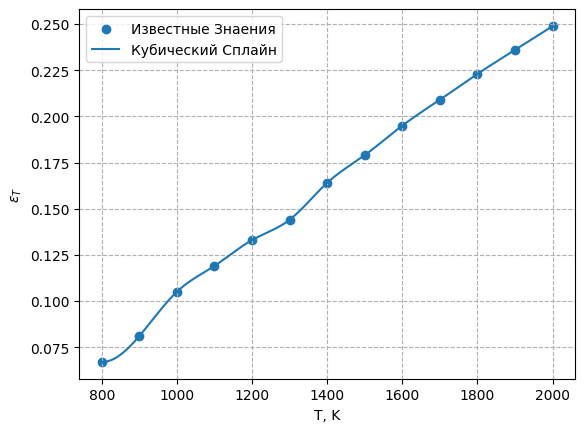

In [43]:
cs = CubicSpline(data_var["T"], data_var["varepsilon"])
# pchip = PchipInterpolator(data_var["T"], data_var["varepsilon"])

T_grid = np.linspace(min(data_var["T"]), max(data_var["T"]), 500)
eps_grid_cs = cs(T_grid)
# eps_grid_pchip = pchip(T_grid)

plt.scatter(data_var["T"], data_var["varepsilon"], label="Известные Знаения")
plt.plot(T_grid, eps_grid_cs, label="Кубический Сплайн")
# plt.plot(T_grid, eps_grid_pchip, label="формо-сохраняющая интерполяция")
plt.xlabel("T, K")
plt.ylabel(r"$\varepsilon_T$")
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig("pics/varepsilon_cubic")
plt.show()

### Получение константы Стефана-Больцмана

$$ \ln \left( W / \varepsilon_T \right) = \ln \left(S \sigma\right) + n \ln T $$

In [49]:
data_III

,t,I,V,W,T_lum,T
0,800,0.491,1.48,0.72668,1073,1155.19
1,900,0.529,1.82,0.96278,1173,1258.19
2,1000,0.547,1.99,1.08853,1273,1361.19
3,1100,0.587,2.38,1.39706,1373,1464.19
4,1200,0.638,2.91,1.85658,1473,1567.19
5,1300,0.697,3.56,2.48132,1573,1670.19
6,1400,0.736,4.00,2.94400,1673,1773.19
7,1500,0.984,7.28,7.16352,1773,1876.19
8,1600,1.093,8.98,9.81514,1873,1979.19


In [ ]:
x = np.log(data_III["T"])
y = np.log(data_III["W"] / cs(data_III["T"]))

In [54]:
def f(x, k, b):
    return k*x + b

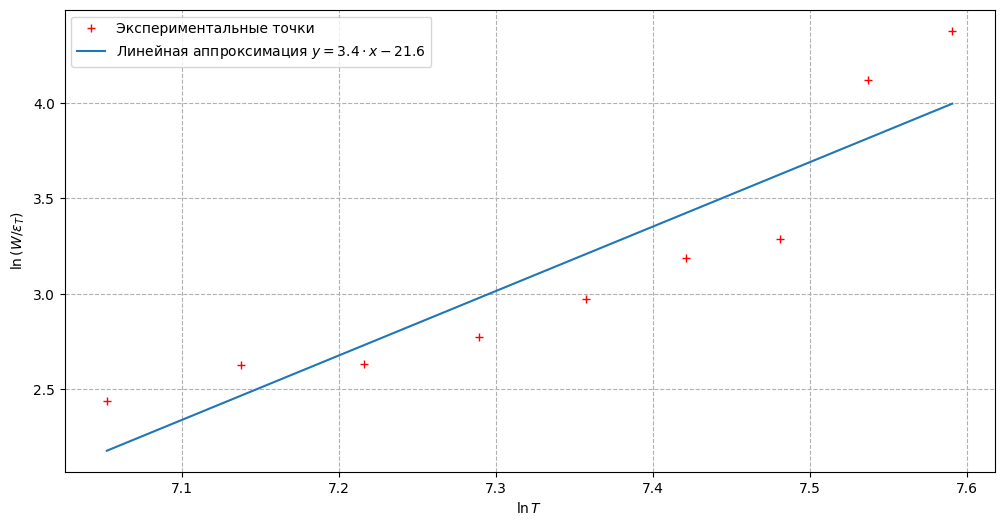

n = 3.4 +- 0.6
b = -21.6 +- 4.2


In [92]:
popt, pcov = curve_fit(f, x, y, p0=(4, -20))

n, b = popt
sigma_n, sigma_b = np.sqrt(np.diag(pcov))

x_model = np.linspace(min(x), max(x), 1000)
y_model = f(x_model, *popt)


plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--')

plt.plot(x, y, '+r', label="Экспериментальные точки")
plt.plot(x_model, y_model, label=rf"Линейная аппроксимация $y = {n:.1f} \cdot x {b:.1f}$")

plt.xlabel(r"$\ln T$")
plt.ylabel(r"$\ln \left( W / \varepsilon_T \right)$")

plt.legend()
plt.savefig("pics/stef_bolts")
plt.show()

print(f"n = {n:.1f} +- {sigma_n:.1f}")
print(f"b = {b:.1f} +- {sigma_b:.1f}")

In [89]:
S = np.float128('0.36e-4')
print(f"S = {S* 1e4} см^2")

S = 0.36 см^2


In [93]:
data_III["varepsilon"] = cs(data_III["T"])

In [94]:
data_III

,t,I,V,W,T_lum,T,varepsilon
0,800,0.491,1.48,0.72668,1073,1155.19,0.126995
1,900,0.529,1.82,0.96278,1173,1258.19,0.138782
2,1000,0.547,1.99,1.08853,1273,1361.19,0.156042
3,1100,0.587,2.38,1.39706,1373,1464.19,0.173965
4,1200,0.638,2.91,1.85658,1473,1567.19,0.189752
5,1300,0.697,3.56,2.48132,1573,1670.19,0.204950
6,1400,0.736,4.00,2.94400,1673,1773.19,0.219284
7,1500,0.984,7.28,7.16352,1773,1876.19,0.232977
8,1600,1.093,8.98,9.81514,1873,1979.19,0.246200


In [101]:
data_III["sigma"] = 1e8*data_III["W"] / (data_III["varepsilon"] * S * data_III["T"]**4)
data_III

,t,I,V,W,T_lum,T,varepsilon,sigma
0,800,0.491,1.48,0.72668,1073,1155.19,0.126995,8.925639
1,900,0.529,1.82,0.96278,1173,1258.19,0.138782,7.689633
2,1000,0.547,1.99,1.08853,1273,1361.19,0.156042,5.644442
3,1100,0.587,2.38,1.39706,1373,1464.19,0.173965,4.853571
4,1200,0.638,2.91,1.85658,1473,1567.19,0.189752,4.505448
5,1300,0.697,3.56,2.48132,1573,1670.19,0.204950,4.321842
6,1400,0.736,4.00,2.94400,1673,1773.19,0.219284,3.772305
7,1500,0.984,7.28,7.16352,1773,1876.19,0.232977,6.892925
8,1600,1.093,8.98,9.81514,1873,1979.19,0.246200,7.217001


In [115]:
sigma = np.mean(data_III["sigma"])
sigma_sigma = np.std(data_III["sigma"], ddof=1)

print(f"sigma = {sigma:.0f} +- {sigma_sigma:.0f}")

sigma = 6 +- 2


для теха

In [110]:
print(*["{:.3f}".format(x) for x in np.array(data_III["W"])], sep=" & ")

0.727 & 0.963 & 1.089 & 1.397 & 1.857 & 2.481 & 2.944 & 7.164 & 9.815


In [111]:
print(*["{:.3f}".format(x) for x in np.array(data_III["varepsilon"])], sep=" & ")

0.127 & 0.139 & 0.156 & 0.174 & 0.190 & 0.205 & 0.219 & 0.233 & 0.246


In [114]:
print(*["{:.3f}".format(x) for x in np.array(data_III["sigma"])], sep=" & ")

8.926 & 7.690 & 5.644 & 4.854 & 4.505 & 4.322 & 3.772 & 6.893 & 7.217


### Постоянная планка

In [119]:
k_b = np.float128('1.36')
c = np.float128('3')

In [120]:
34 + (-23 * 4 - 2*8 + 8) / 3

0.6666666666666643

In [121]:
data_III["h"] = np.power(2 * np.pi**5 * k_b**4 / 15 /  c**2 / data_III["sigma"], 1/3) * np.power(10, 34 + (-23 * 4 - 2*8 + 8) / 3)
data_III

,t,I,V,W,T_lum,T,varepsilon,sigma,h
0,800,0.491,1.48,0.72668,1073,1155.19,0.126995,8.925639,5.580254
1,900,0.529,1.82,0.96278,1173,1258.19,0.138782,7.689633,5.864512
2,1000,0.547,1.99,1.08853,1273,1361.19,0.156042,5.644442,6.501198
3,1100,0.587,2.38,1.39706,1373,1464.19,0.173965,4.853571,6.836701
4,1200,0.638,2.91,1.85658,1473,1567.19,0.189752,4.505448,7.008435
5,1300,0.697,3.56,2.48132,1573,1670.19,0.204950,4.321842,7.106310
6,1400,0.736,4.00,2.94400,1673,1773.19,0.219284,3.772305,7.435865
7,1500,0.984,7.28,7.16352,1773,1876.19,0.232977,6.892925,6.082273
8,1600,1.093,8.98,9.81514,1873,1979.19,0.246200,7.217001,5.989834


In [122]:
print(*["{:.3f}".format(x) for x in np.array(data_III["h"])], sep=" & ")

5.580 & 5.865 & 6.501 & 6.837 & 7.008 & 7.106 & 7.436 & 6.082 & 5.990


In [123]:
h = np.mean(data_III["h"])
h_sigma = np.std(data_III["h"], ddof=1)

print(f"h = {h:.0f} +- {h_sigma:.0f}")

h = 6 +- 1


## IV. Измерение неоновой лампы

In [124]:
t_Ne = 823 # C